In [1]:
# 사전 라이브러리 설치(XAI용, XAI: 실현가능한 AI) : pip install shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error 
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.impute import SimpleImputer    # 결측치를 처리하는데 사용
from sklearn.preprocessing import LabelEncoder    #범주형 데이터를 숫자형 데이터로 변환하는 데 사용
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.layers import Activation
import shap  # feature importance와 유사 (LSTM에 사용)

c:\AIProject\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 데이터 불러오기
df = pd.read_csv("dataset/All_Feature_Data.csv", encoding='cp949')
df.head()


,Date,GMSL,CO2 conc.,CO2 emissions,Long-run NO2 concentration,Per-capita NO2 emissions in CO2 equivalents,Long-run CH4 concentration,Per-capita methane emissions in CO2 equivalents,Global avg temp. anomaly relative to 1961-1990,Sea surface temperature anomaly (relative to 1961-90 average),...,Nino 3.4 trend,North Sea Ice Extent Avg,North Sea Ice Extent Min,South Sea Ice Extent Avg trend,South Sea Ice Extent Max,South Sea Ice Extent Max trend,South Sea Ice Extent Min,South Sea Ice Extent Avg,South Sea Ice Extent Avg Raw,South Sea Ice Extent Raw Avg trend
0,31/01/1880,-180.236283,287.770720,858055700.0,275.6600,0.168686,845.190000,1.090627,-0.315832,-0.203400,...,-0.821954,17.604087,15.354746,10.977710,18.800729,17.193305,3.751963,12.241826,12.294841,10.692674
1,29/02/1880,-179.636515,287.901087,860548141.7,275.6725,0.168764,845.280833,1.091156,-0.308867,-0.199175,...,-0.821443,17.599791,15.348261,10.978137,18.800490,17.194206,3.751442,12.241333,12.294623,10.693583
2,31/03/1880,-179.036747,288.031454,863040583.3,275.6850,0.168843,845.371667,1.091684,-0.301901,-0.194950,...,-0.820931,17.595494,15.341776,10.978564,18.800252,17.195108,3.750921,12.240839,12.294405,10.694492
3,30/04/1880,-178.436979,288.161821,865533025.0,275.6975,0.168921,845.462500,1.092212,-0.294935,-0.190725,...,-0.820420,17.591198,15.335291,10.978991,18.800013,17.196009,3.750400,12.240345,12.294187,10.695401
4,31/05/1880,-177.837210,288.292188,868025466.7,275.7100,0.168999,845.553333,1.092741,-0.287970,-0.186500,...,-0.819909,17.586901,15.328807,10.979417,18.799774,17.196911,3.749879,12.239852,12.293968,10.696310


In [3]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [4]:
# 날짜(Date)열의 이름 설정 및 변환
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

C:\Users\최주철\AppData\Local\Temp\ipykernel_24552\297825193.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [5]:
# 결측치 확인
print("데이터 결측치 확인:")
print(df.isnull().sum())

데이터 결측치 확인:
GMSL                                                                     0
CO2 conc.                                                                0
CO2 emissions                                                            0
Long-run NO2 concentration                                               0
Per-capita NO2 emissions in CO2 equivalents                              0
Long-run CH4 concentration                                               0
Per-capita methane emissions in CO2 equivalents                          0
Global avg temp. anomaly relative to 1961-1990                           0
Sea surface temperature anomaly (relative to 1961-90 average)            0
Sea surface temperature anomaly (relative to 1961-90 average) trend      0
Sea surface temperature anomaly (relative to 1961-90 average) anomaly    0
Nino 3.4 trend                                                           0
North Sea Ice Extent Avg                                                 0
North Sea Ice

상위 10개 컬럼명:
['GMSL', 'CO2 conc.', 'CO2 emissions', 'Long-run NO2 concentration', 'Per-capita NO2 emissions in CO2 equivalents', 'Long-run CH4 concentration', 'Per-capita methane emissions in CO2 equivalents', 'Global avg temp. anomaly relative to 1961-1990', 'Sea surface temperature anomaly (relative to 1961-90 average)', 'Sea surface temperature anomaly (relative to 1961-90 average) trend']


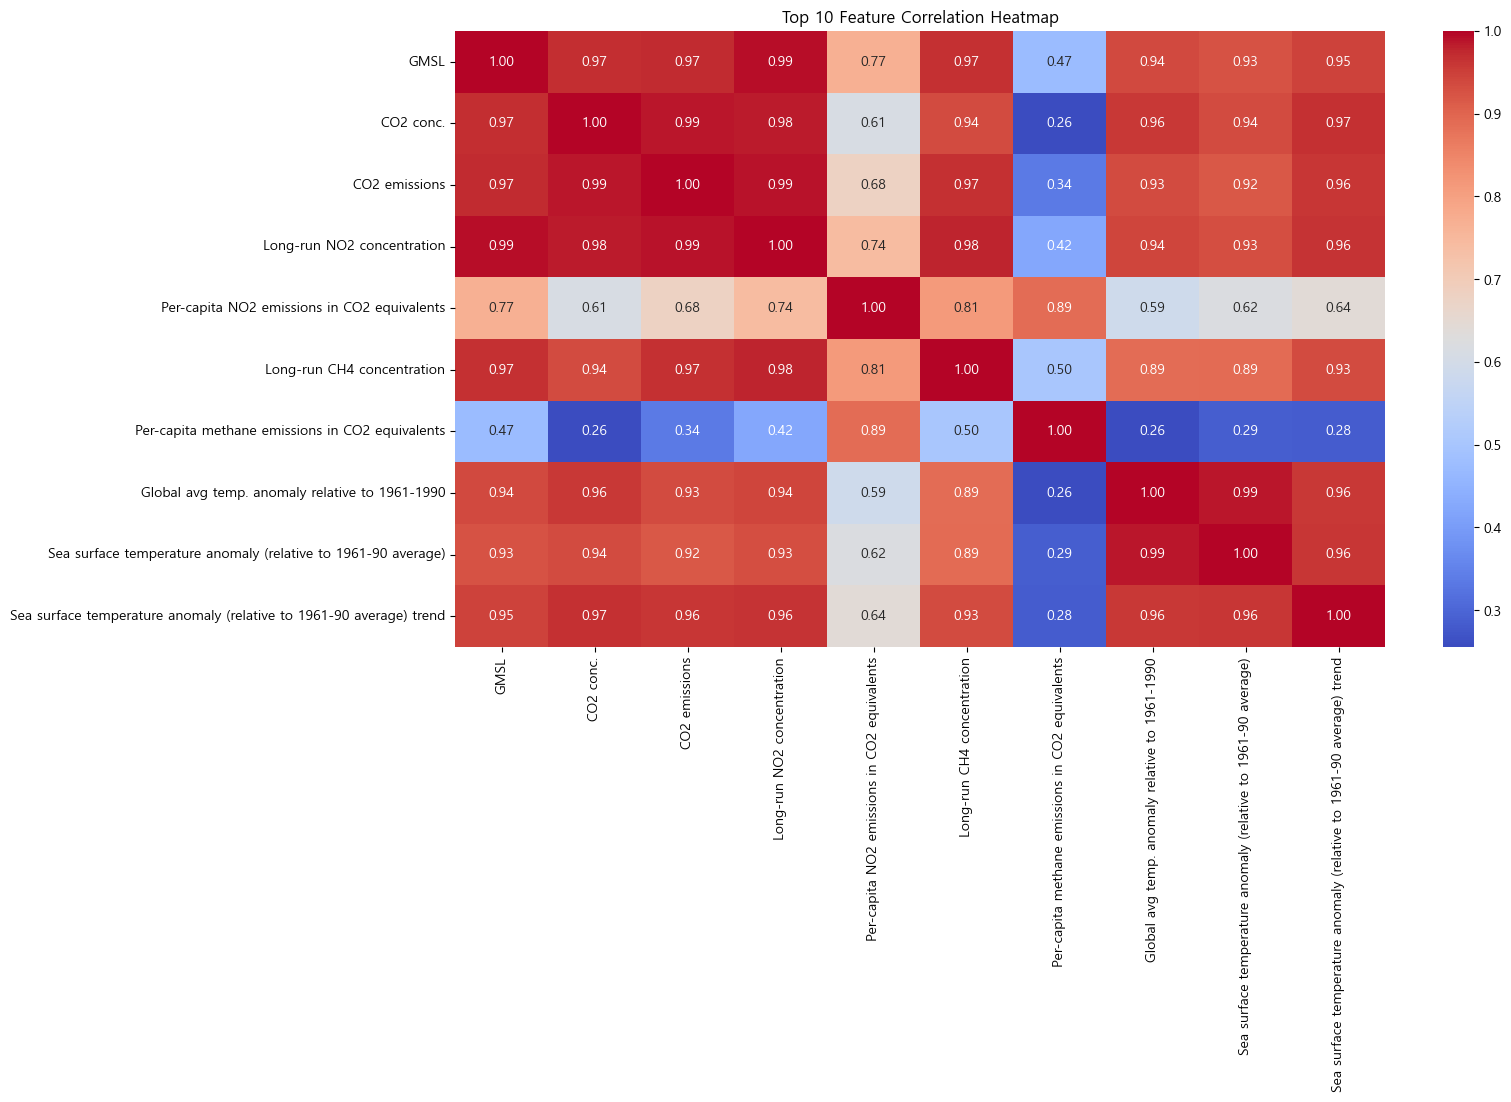

In [6]:
# 상위 10개 컬럼 선택
top_10_cols = df.iloc[:, :10]

# 상위 10개 컬럼명 출력
print("상위 10개 컬럼명:")
print(top_10_cols.columns.tolist())

# 그래프 출력
plt.figure(figsize=(15, 8))  # 그래프 크기 설정
sns.heatmap(top_10_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")  # 상관관계 히트맵
plt.title('Top 10 Feature Correlation Heatmap')  # 그래프 제목
plt.show()  # 그래프 출력

In [7]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['GMSL']])

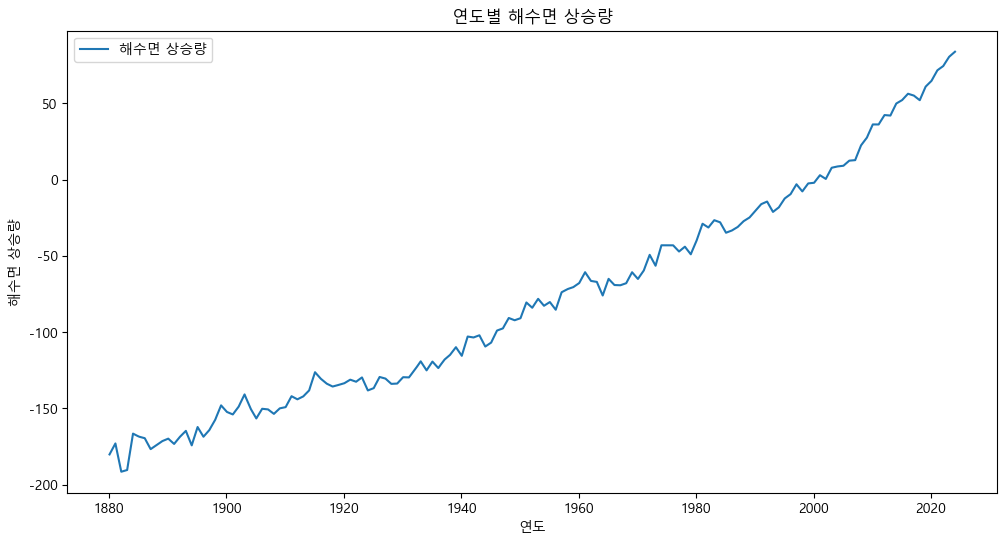

In [8]:
# 데이터 시각화
plt.figure(figsize=(12, 6))
plt.plot(df['GMSL'], label='해수면 상승량')
plt.title('연도별 해수면 상승량')
plt.xlabel('연도')
plt.ylabel('해수면 상승량')
plt.legend()
plt.show()

In [9]:
# 데이터셋 분리 (학습 데이터와 테스트 데이터)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [10]:
# 시계열 데이터셋 생성 함수 (다변량 입력)
def create_dataset(data, time_step=12, target_idx=0):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step, :])  # 모든 피처 사용
        y.append(data[i + time_step, target_idx])  # GMSL 예측
    return np.array(X), np.array(y)

In [11]:
time_step = 12  # 12개월 단위로 예측
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [12]:
# LSTM 입력에 맞게 데이터 형태 변경
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [13]:
# LSTM 모델 생성
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

c:\AIProject\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

In [15]:
# 조기 종료 설정
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [16]:
# 모델 학습
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0312 - val_loss: 9.6711e-05
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.1699e-04 - val_loss: 9.5933e-04
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3981e-04 - val_loss: 2.5002e-04
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0378e-04 - val_loss: 9.7413e-05
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4255e-04 - val_loss: 1.7463e-04
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9460e-04 - val_loss: 1.8606e-04
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9963e-04 - val_loss: 1.4940e-04
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0423e-04 - val_loss: 8.5845e-05
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7395e-04 - val_loss: 1.5364e-04
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9185e-04 - val_loss: 9.4184e-05
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7992e-04 -

In [17]:
# 학습이 몇 번째 에폭에서 멈췄는지 확인
actual_epochs = len(history.history['loss'])
print(f"학습이 {actual_epochs}번째 에폭에서 완료되었습니다.")

학습이 48번째 에폭에서 완료되었습니다.


In [18]:
#모델 저장 (HDF5 포맷)
model.save('trained_model.h5')

print("모델이 저장되었습니다!")

모델이 저장되었습니다!


In [19]:
from tensorflow.keras.models import load_model

# 저장된 모델 불러오기
loaded_model = load_model('trained_model.h5')

print("모델이 성공적으로 불러와졌습니다!")


모델이 성공적으로 불러와졌습니다!


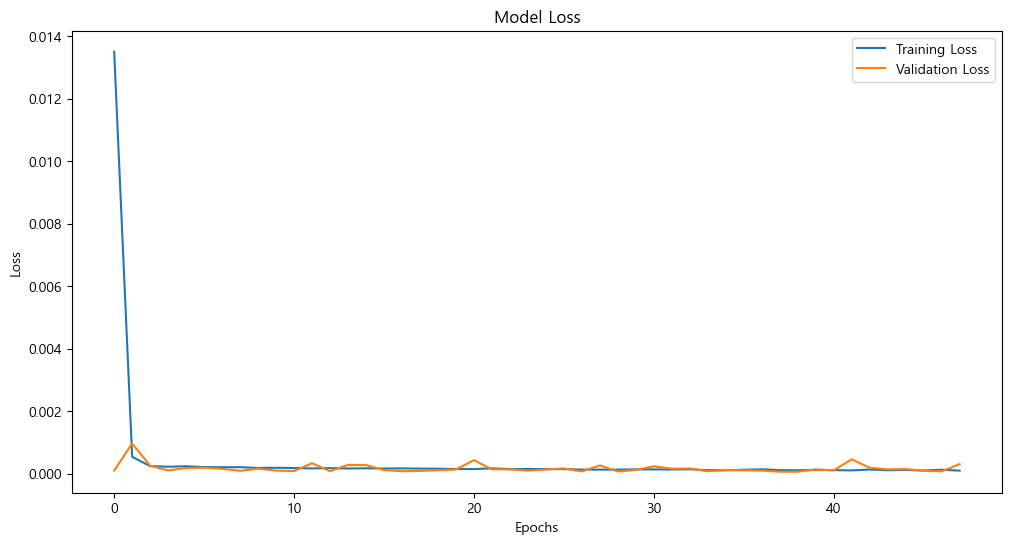

In [20]:
# 학습 과정 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
# 테스트 데이터 예측
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [22]:
# 예측값 역정규화
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

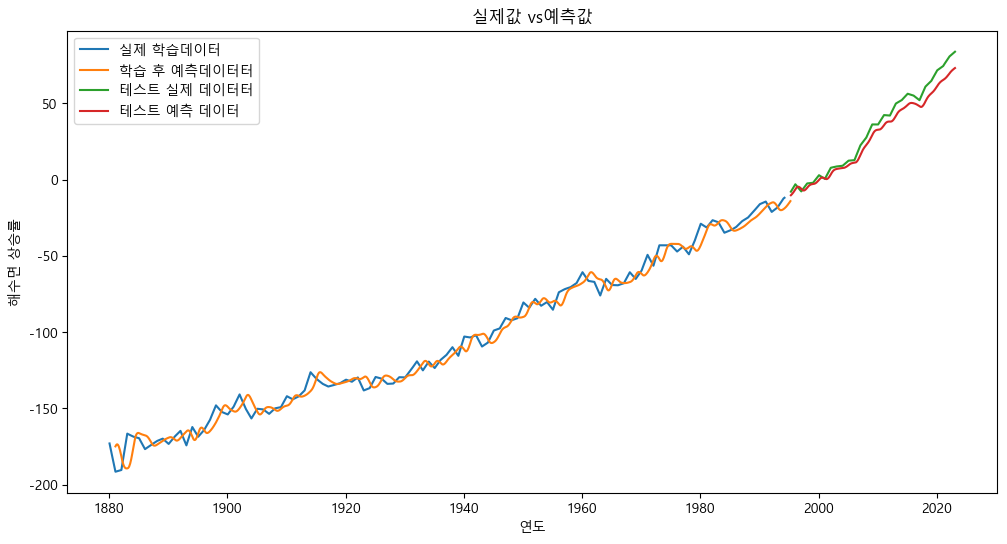

In [23]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[:len(y_train)], y_train, label='실제 학습데이터')
plt.plot(df.index[time_step:len(train_predict) + time_step], train_predict, label='학습 후 예측데이터터')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], y_test, label='테스트 실제 데이터터')
plt.plot(df.index[len(train_data):len(train_data) + len(test_predict)], test_predict, label='테스트 예측 데이터')
plt.title('실제값 vs예측값')
plt.xlabel('연도')
plt.ylabel('해수면 상승률')
plt.legend()
plt.show()

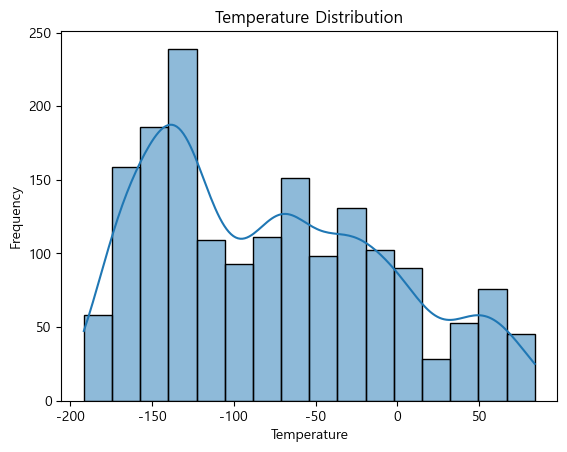

In [24]:
# 변수 분포 시각화
# 예시: 'Temp' 변수의 분포 시각화
sns.histplot(df['GMSL'], kde=True)
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

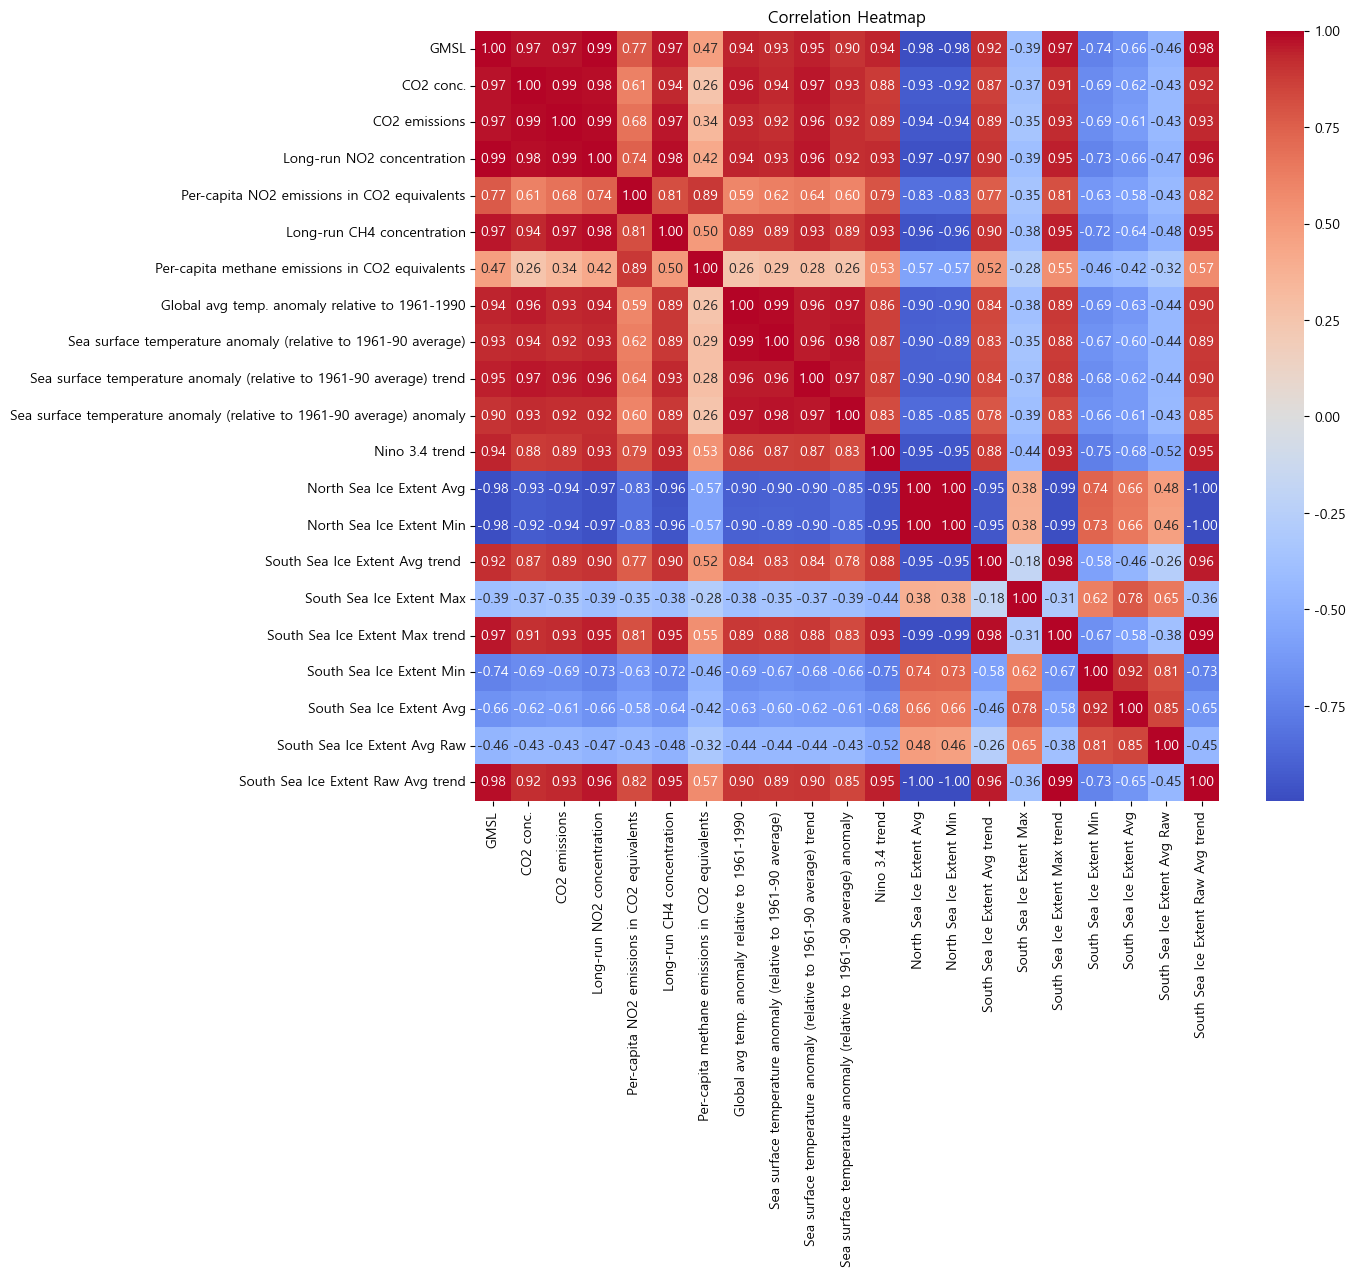

In [25]:
# 변수 간 상관관계 시각화
# 상관관계 행렬 계산
correlation_matrix = df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [26]:
# 평가 지표 계산 및 출력
rmse = np.sqrt(mean_squared_error(y_test, test_predict))
mae = mean_absolute_error(y_test, test_predict)
r2 = r2_score(y_test, test_predict)
mape = mean_absolute_percentage_error(y_test, test_predict)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}")

RMSE: 5.8725
MAE: 5.0258
R²: 0.9554
MAPE: 1.9536


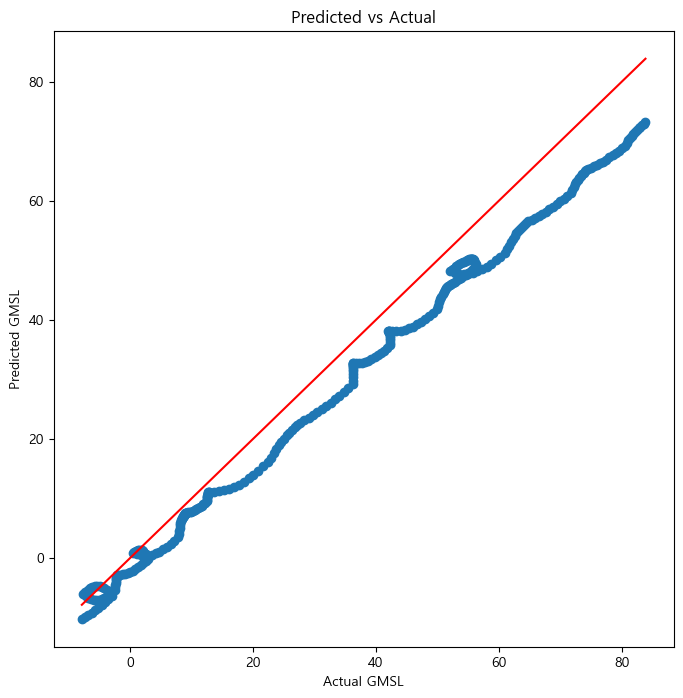

In [27]:
# 예측값 vs 실제값 산점도
plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_predict)
plt.plot(y_test, y_test, color='red')  # y=x 직선 (완벽한 예측)
plt.title('Predicted vs Actual')
plt.xlabel('Actual GMSL')
plt.ylabel('Predicted GMSL')
plt.show()

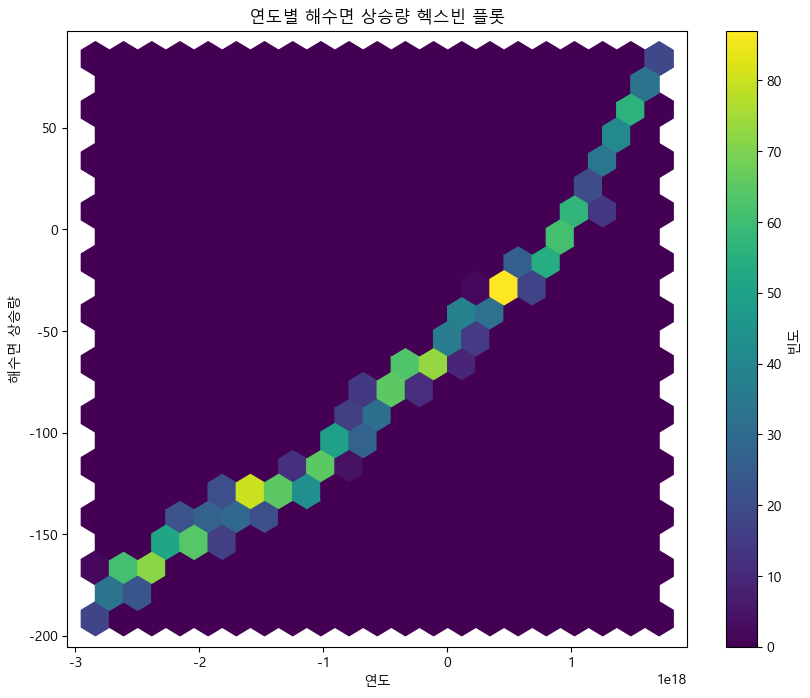

In [28]:
# 헥스빈 플롯 추가
plt.figure(figsize=(10, 8))
plt.hexbin(df.index.astype(int), df['GMSL'], gridsize=20, cmap='viridis')
plt.colorbar(label='빈도')
plt.title('연도별 해수면 상승량 헥스빈 플롯')
plt.xlabel('연도')
plt.ylabel('해수면 상승량')
plt.show()

In [29]:
import os
import pandas as pd
from ydata_profiling import ProfileReport

# 데이터 정보 출력
print(df.info())

# 데이터 불러오기
df = pd.read_csv('./dataset/All_Feature_Data.csv', encoding='cp949')

# 프로파일링 리포트 생성
profile = ProfileReport(
    df,
    title="해수면 상승율 예측측 보고서",
    explorative=True,
    html={
        'style': {
            'theme': 'united'  # 허용된 theme 중 하나로 변경
        }
    }
)

# 리포트 저장 및 출력
profile.to_file("./report/sea_report.html")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1729 entries, 1880-01-31 to 2024-01-31
Data columns (total 21 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   GMSL                                                                   1729 non-null   float64
 1   CO2 conc.                                                              1729 non-null   float64
 2   CO2 emissions                                                          1729 non-null   float64
 3   Long-run NO2 concentration                                             1729 non-null   float64
 4   Per-capita NO2 emissions in CO2 equivalents                            1729 non-null   float64
 5   Long-run CH4 concentration                                             1729 non-null   float64
 6   Per-capita methane emissions in CO2 equivalents                       

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 12.08it/s]
